In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
R, C = 10 * 1E3, 4.7 * 1E-9 # Ohms, Farads
alpha = 1 / (R * C) # Hz

omega = 1E9 # Hz
A_in = 14.4 # V

T = 1/omega
#H_V = 1 / np.sqrt(1 + (omega / alpha)**2)
H_V = 1 / np.sqrt(1 + (omega / alpha)**2)
phi = np.arctan(-omega / alpha)

t = np.linspace(-T, T, 1000)
V_in, V_out = 0.5*A_in*np.sin(2*np.pi*omega * t), 0.5*A_in*H_V*np.sin(2*np.pi*omega*t - 2*np.pi*phi)
a_in, a_out = np.max(V_in)-np.min(V_in), np.max(V_out)-np.min(V_in)

print(f'A_in: {a_in} V')
print(f'A_out: {a_out} V')

A_in: 14.399982199131804 V
A_out: 7.200144290429954 V


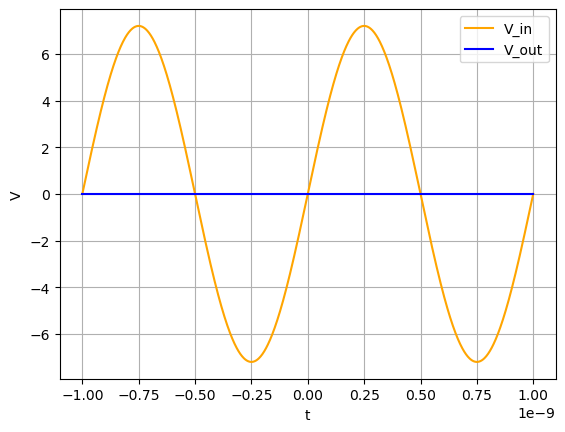

In [3]:
fig, ax = plt.subplots()
ax.plot(t, V_in, label="V_in", color = "orange")
ax.plot(t, V_out, label="V_out", color = "blue")
ax.set(xlabel="t", ylabel="V")
ax.grid(True)
plt.legend()
plt.show()

In [138]:
f = 1
R, C = 10 * 1E3, 4.7 * 1E-9 # Ohms, Farads
alpha = 1 / (R * C) # Hz

key_words = ["Low-pass", "High-pass", "Gaussian"]
kw = ["low_pass", "high_pass", "gaussian"]
data_list = ["20250911_C1_SINE.csv", "20250911_C2_SINE.csv", "20250911_C3_SINE.csv"]

In [139]:
df = pd.read_csv(data_list[f]) 
df_Hv = (df["V_out[V]"] - df["noise[V]"]) / df["V_in[V]"]
df_phase = -2*np.pi*1E-6*df["lag[us]"]

delta_in = 0.03*df["V_in[V]"] + 0.02*df["V_scale_in[V]"] + 0.005
delta_out = 0.03*df["V_out[V]"] + 0.02*df["V_scale_out[V]"] + 0.005
delta_noise = 0.03*df["noise[V]"] +  0.02*df["V_scale_out[V]"] + 0.005

delta_df_Hv = delta_in*(df["V_out[V]"] - df["noise[V]"]) / (df["V_in[V]"]**2) + (delta_out+delta_noise)/ df["V_in[V]"]
per_delta_df_Hv = delta_df_Hv/df_Hv

delta_f = 0.1
delta_lag = df["t_scale[us]"]/250 + 50E-6*df["lag[us]"] + 0.06E-3

df_HvdB = 20 * np.log10(df_Hv)
df_HvdB_err = np.abs(df_HvdB*per_delta_df_Hv)

df_phi = df_phase*df["f_in[Hz]"]
df_phi_err = 2*np.pi*1E-6*(df["lag[us]"]*delta_f+ df["f_in[Hz]"]*delta_lag)

df_omega = 2*np.pi*df["f_in[Hz]"]
df_omega_err = delta_f*df_omega/df["f_in[Hz]"]

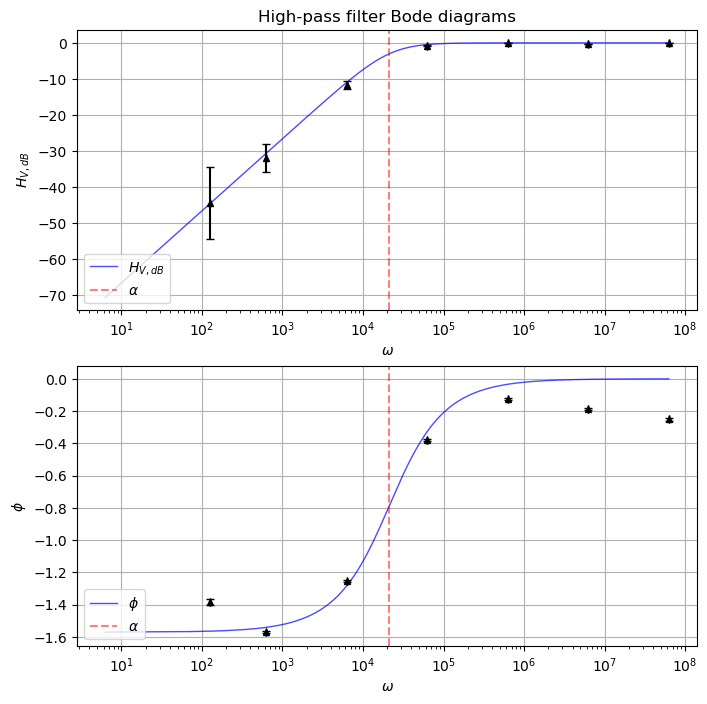

In [141]:
Omega = 2*np.pi*np.linspace(1, 1E7, int(1E6))

if f == 1:
    H_V_dB = 20 * np.log10(1 / np.sqrt(1 + (alpha / Omega)**2)) #high-pass filter
    phase = np.arctan(-alpha/Omega)
elif f == 2:
    H_V_dB = 20 * np.log10(1 / np.sqrt(1 + (Omega / alpha)**2)) #low-pass filter
    phase = np.arctan(-Omega/alpha)
elif f == 3:
    H_V_dB = 20 * np.log10(np.sqrt((2*R2*(R1+2*R2)+Z**2)**2+(Z**2)*(R1**2)) / ((R1+2*R2)**2 + Z**2)) #band-reject filter
    
log_omega = np.log10(Omega)
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(2,1,1)
bx = fig.add_subplot(2,1,2)

ax.plot(Omega, H_V_dB, color="b", linewidth = 1, alpha = 0.7, label = "$H_{V,dB}$")
ax.errorbar(df_omega, df_HvdB,xerr = df_omega_err, yerr = df_HvdB_err,fmt= '^' ,capsize=3, ecolor='k', color = 'k', ms = 5)
ax.axvline(alpha, color="r", ls="--", label=f"$\\alpha$", alpha = 0.5)
ax.set(xlabel="$\omega$", ylabel="$H_{V,dB}$")

bx.plot(Omega, phase, color = "b", linewidth = 1, alpha =0.7, label="$\phi$")
bx.errorbar(df_omega,df_phi,xerr= df_omega_err, yerr = df_phi_err, fmt= '^' ,capsize=3, ecolor='k', color = 'k', ms = 5)
bx.axvline(alpha, color="r", ls="--", label=f"$\\alpha$", alpha = 0.5)
bx.set(xlabel="$\omega$", ylabel="$\phi$")

ax.set_xscale('log'), bx.set_xscale('log')
ax.legend(loc = 3), bx.legend(loc =3)
ax.grid(), bx.grid()

ax.set_title("High-pass filter Bode diagrams")
plt.savefig("high_pass_filter_bode.png")
plt.show()

In [117]:
'''weird filter'''
R1, R2, C = 220, 100, 0.68 * 1E-6 # Ohms, Farads
omega = 1E9 # Hz
A_in = 14.4 # V

T = 1/omega
z = R1*R2*omega*C-1/(omega*C)
H_V = np.sqrt((2*R2*(R1+2*R2)+z**2)**2+(z**2)*(R1**2)) / ((R1+2*R2)**2 + z**2)
phi = np.arctan(z*R1/(2*R2*(R1+2*R2)))

t = np.linspace(-T, T, 1000)
V_in, V_out = 0.5*A_in*np.sin(2*np.pi*omega * t), 0.5*A_in*H_V*np.sin(2*np.pi*omega*t - 2*np.pi*phi)
a_in, a_out = np.max(V_in)-np.min(V_in), np.max(V_out)-np.min(V_in)

print(f'A_in: {a_in} V')
print(f'A_out: {a_out} V')

A_in: 14.399982199131804 V
A_out: 14.399990741829647 V


In [130]:
df = pd.read_csv("20250911_C3_SINE.csv")
df_Hv = (df["V_out[V]"] - df["noise[V]"]) / df["V_in[V]"]

In [ ]:
f = np.linspace(1, 1E7, int(1E6))
Omega = f*2*np.pi
Z = R1*R2*Omega*C-1/(Omega*C)
H_V_dB = 20 * np.log10(np.sqrt((2*R2*(R1+2*R2)+Z**2)**2+(Z**2)*(R1**2)) / ((R1+2*R2)**2 + Z**2)) #band-reject filter
log_omega = np.log10(f)

fig, ax = plt.subplots()
ax.plot(log_omega, H_V_dB, color="k", alpha=0.8)
ax.scatter(np.log10(df["f_in[Hz]"]), 20 * np.log10(df_Hv), s = 10, marker="o", color="b")

ax.set(xlabel="$log(\omega)$", ylabel="$H_{V,dB}$")

plt.grid()
plt.show()